# LSTM - Carteira Utilities Brasileiras (B3)
### Versao auditada e corrigida

**Mercado:** B3 - Setor de Transmissao e Geracao de Energia Eletrica  
**Acoes:** CPFE3 · TAEE11 · EGIE3  
**Framework:** PyTorch  
**Periodo base:** 2019 completo + 2023 em diante (2020-2022 excluido)  
**Objetivo desta etapa:** preparar os dados para testar em 2025 completo; se 2025 estiver incompleto, testar em 2024 e descartar 2025.

# Coleta de Dados, Pré-processamento e análises.

##  Justificativa da Carteira - Visao do Economista

### Por que Utilities de Energia Eletrica?

| Ticker | Empresa | Segmento | Vol. 12m | Justificativa |
|--------|---------|----------|----------|---------------|
| `CPFE3.SA` | CPFL Energia | Distribuicao | ~20% | Receita regulada ANEEL, contratos de longo prazo |
| `TAEE11.SA` | Taesa | Transmissao | ~19% | Concessoes longas e previsibilidade operacional |
| `EGIE3.SA` | Engie Brasil | Geracao | ~20% | Escala relevante no setor e contratos de energia |

### Correlacao setorial: moderada e heterogenea
As empresas compartilham fatores de risco setoriais, mas a intensidade nao e uniforme entre pares.
A expectativa tecnica para os retornos e de correlacao positiva em parte dos pares, sem assumir bloco altamente co-movente.

Fatores estruturais comuns:
1. Regulatorio (ANEEL e regras tarifarias)
2. Macroeconomico (juros e custo de capital)
3. Hidrologico e energetico (condicoes de geracao)
4. Fluxo de investidores de perfil defensivo

### Por que excluir 2020-2022?
O periodo pandemico introduziu choques nao recorrentes: queda atipica de demanda (2020),
crise hidrica relevante (2021) e mudancas emergenciais no marco regulatorio.
Incluir esse regime tende a confundir o aprendizado de dinamicas mais estaveis do periodo base.

##  Instalação de Dependências

In [1]:
%pip install yfinance matplotlib scikit-learn scipy statsmodels --quiet
print('Dependencias principais instaladas.')

Dependencias principais instaladas.


## Imports e Configuração

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings, random, time, sys, subprocess
from copy import deepcopy
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)

def check_torch_import(timeout_seconds: int = 90):
    """
    Testa import do torch em subprocesso para evitar travamento silencioso da sessao atual.
    """
    cmd = [sys.executable, "-c", "import torch; print(torch.__version__)" ]
    try:
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout_seconds)
    except subprocess.TimeoutExpired:
        raise RuntimeError(
            "Import de torch excedeu o tempo limite. "
            "No notebook, execute: %pip install --upgrade --force-reinstall --no-cache-dir torch"
        )

    if proc.returncode != 0:
        stderr_msg = (proc.stderr or "").strip()
        raise RuntimeError(
            "Falha ao importar torch no ambiente atual. "
            "No notebook, execute: %pip install --upgrade --force-reinstall --no-cache-dir torch\n"
            f"Detalhe: {stderr_msg}"
        )

    return (proc.stdout or "").strip()

seed_everything(42)
torch_version = check_torch_import(timeout_seconds=90)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

seed_everything(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE} | PyTorch: {torch.__version__}")
print(f"Check subprocess torch: {torch_version}")

Dispositivo: cpu | PyTorch: 2.10.0+cpu
Check subprocess torch: 2.10.0+cpu


## Coleta de Dados - Yahoo Finance

Baixamos dois blocos de dados preservando a ordem cronologica:
- **2019 completo** (regime pre-pandemia)
- **2023 em diante** (regime pos-pandemia)

 > **Nota sobre o grafico de precos:** a linha reta entre o fim de 2019 e o inicio de 2023 e apenas interpolacao 
 > visual do matplotlib sobre o gap sem dados de 2020-2022. O pipeline descarta janelas que cruzam esse gap.

Baixando dados do Yahoo Finance...
------------------------------------------------------------------------------------------
CPFE3.SA     | CPFL Energia         | 2019-01-02 -> 2025-12-30 | 997 pregoes | anos: [2019, 2023, 2024, 2025]
  Pregoes por ano: {2019: 248, 2023: 248, 2024: 251, 2025: 250}
TAEE11.SA    | Taesa                | 2019-01-02 -> 2025-12-30 | 997 pregoes | anos: [2019, 2023, 2024, 2025]
  Pregoes por ano: {2019: 248, 2023: 248, 2024: 251, 2025: 250}
EGIE3.SA     | Engie Brasil         | 2019-01-02 -> 2025-12-30 | 997 pregoes | anos: [2019, 2023, 2024, 2025]
  Pregoes por ano: {2019: 248, 2023: 248, 2024: 251, 2025: 250}


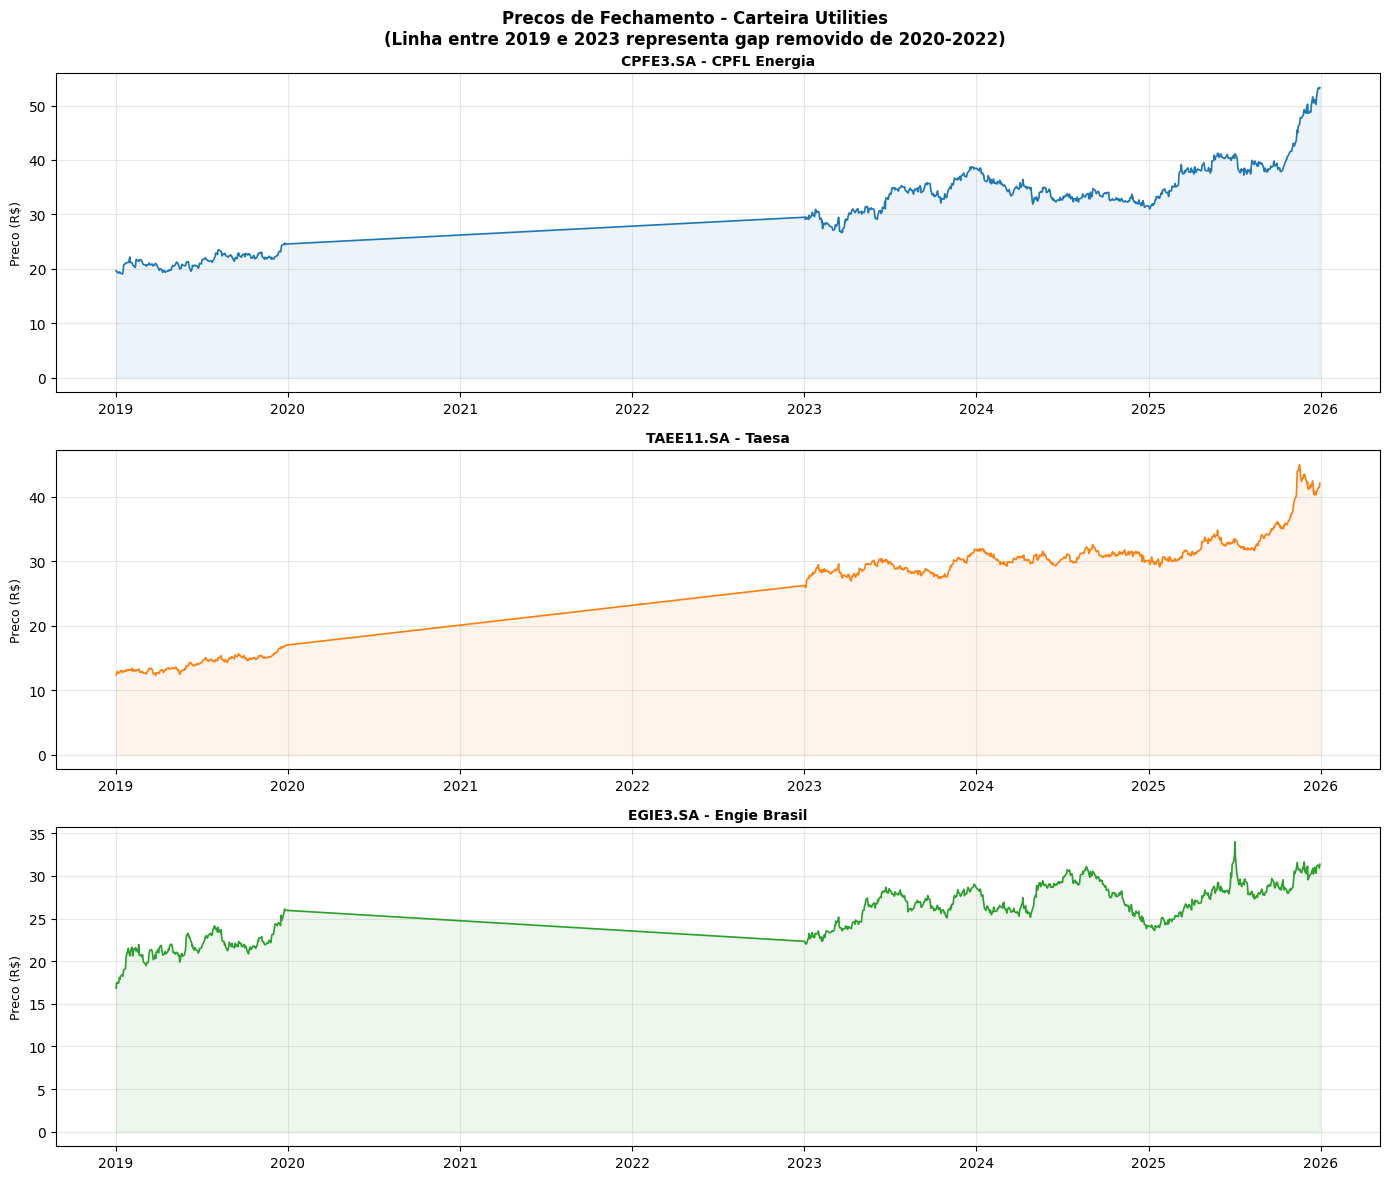


Coleta concluida.


In [3]:
TICKERS = ['CPFE3.SA', 'TAEE11.SA', 'EGIE3.SA']
NOMES = {
    'CPFE3.SA': 'CPFL Energia',
    'TAEE11.SA': 'Taesa',
    'EGIE3.SA': 'Engie Brasil'
}
CORES = {'CPFE3.SA': '#1f77b4', 'TAEE11.SA': '#ff7f0e', 'EGIE3.SA': '#2ca02c'}

PERIODOS = [
    ('2019-01-01', '2019-12-31'),
    # Em yfinance, o parametro end e exclusivo; 2026-01-01 garante captura completa de 2025.
    ('2023-01-01', '2026-01-01'),
]

def resumo_pregoes_por_ano(df: pd.DataFrame) -> pd.Series:
    return df.groupby(df.index.year).size().sort_index()

print('Baixando dados do Yahoo Finance...')
print('-' * 90)

raw_dfs = {}
for ticker in TICKERS:
    frames = []
    for start, end in PERIODOS:
        df_dl = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if not df_dl.empty:
            frames.append(df_dl)

    if not frames:
        print(f'{ticker}: sem dados no recorte solicitado.')
        continue

    df_t = pd.concat(frames).sort_index()
    df_t = df_t[(df_t.index.year == 2019) | (df_t.index.year >= 2023)]
    raw_dfs[ticker] = df_t

TICKERS = list(raw_dfs.keys())
if len(TICKERS) == 0:
    raise ValueError('Nenhum ticker retornou dados para o periodo definido.')

for ticker in TICKERS:
    df = raw_dfs[ticker]
    anos = sorted(df.index.year.unique().tolist())
    pregoes_ano = resumo_pregoes_por_ano(df)
    print(
        f'{ticker:12s} | {NOMES[ticker]:20s} | '
        f'{df.index[0].date()} -> {df.index[-1].date()} | {len(df)} pregoes | anos: {anos}'
    )
    print(f'  Pregoes por ano: {pregoes_ano.to_dict()}')

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 4 * len(TICKERS)))
if len(TICKERS) == 1:
    axes = [axes]

fig.suptitle(
    'Precos de Fechamento - Carteira Utilities\n'
    '(Linha entre 2019 e 2023 representa gap removido de 2020-2022)',
    fontsize=12,
    fontweight='bold'
 )

for ax, ticker in zip(axes, TICKERS):
    close = raw_dfs[ticker]['Close'].squeeze()
    ax.plot(raw_dfs[ticker].index, close, color=CORES[ticker], lw=1.2)
    ax.fill_between(raw_dfs[ticker].index, close, alpha=0.08, color=CORES[ticker])
    ax.set_title(f'{ticker} - {NOMES[ticker]}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Preco (R$)', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('\nColeta concluida.')

## Engenharia de Variáveis Financeiras

### Features construídas (23 no total)

| Grupo | Features | Observação |
|-------|----------|------------|
| Preço | Close*, High, Low, Open | *Close = col 0 (target anchor) |
| Médias Móveis | SMA_14, EMA_9, EMA_14, EMA_21, SMA_20 | Escalam com preço → divididas pelo anchor |
| Momentum | RSI_14, MACD, MACD_Signal, MACD_Hist | MACD escala com preço; RSI não |
| Volatilidade | BB_Upper, BB_Lower, BB_Width, ATR_14 | BB_Width é ratio → independente de preço |
| Volume | Volume, Volume_MA10, Volume_Ratio | Volume escala absurdamente → normalizado separado |
| Retornos | Ret_1d, Ret_5d, Ret_10d | Já em % → independentes de preço |

### Índices por tipo de normalização

```python
PRICE_IDX = [0,1,2,3,4,5,6,7,8,10,11,12,13,14,16]  # ÷ anchor (escalam com preço)
OTHER_IDX  = [9,15,17,18,19,20,21,22]               # MinMaxScaler fit no treino
```

In [4]:
def contiguous_blocks(index: pd.DatetimeIndex, max_gap_days: int = 30):
    """Retorna lista de slices para blocos temporais sem lacunas longas."""
    if len(index) == 0:
        return []
    blocks = []
    start = 0
    for i in range(1, len(index)):
        if (index[i] - index[i - 1]).days > max_gap_days:
            blocks.append(slice(start, i))
            start = i
    blocks.append(slice(start, len(index)))
    return blocks


def build_features(raw_df: pd.DataFrame, ticker: str, max_gap_days: int = 30) -> pd.DataFrame:
    """
    Construcao de features por blocos continuos para evitar contaminacao do gap 2019->2023.
    """
    close = raw_df['Close'].squeeze()
    high = raw_df['High'].squeeze()
    low = raw_df['Low'].squeeze()
    open_ = raw_df['Open'].squeeze()
    volume = raw_df['Volume'].squeeze()

    pieces = []
    for s in contiguous_blocks(close.index, max_gap_days=max_gap_days):
        c = close.iloc[s]
        h = high.iloc[s]
        l = low.iloc[s]
        o = open_.iloc[s]
        v = volume.iloc[s]

        f = pd.DataFrame(index=c.index)

        # Preco - col 0 = target anchor.
        f['Close'] = c
        f['High'] = h
        f['Low'] = l
        f['Open'] = o

        # Medias moveis.
        f['SMA_14'] = c.rolling(14).mean()
        f['EMA_9'] = c.ewm(span=9, adjust=False).mean()
        f['EMA_14'] = c.ewm(span=14, adjust=False).mean()
        f['EMA_21'] = c.ewm(span=21, adjust=False).mean()
        f['SMA_20'] = c.rolling(20).mean()

        # RSI_14.
        delta = c.diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        f['RSI_14'] = 100 - (100 / (1 + gain / loss))

        # MACD.
        ema12 = c.ewm(span=12, adjust=False).mean()
        ema26 = c.ewm(span=26, adjust=False).mean()
        f['MACD'] = ema12 - ema26
        f['MACD_Signal'] = f['MACD'].ewm(span=9, adjust=False).mean()
        f['MACD_Hist'] = f['MACD'] - f['MACD_Signal']

        # Bollinger Bands.
        std20 = c.rolling(20).std()
        f['BB_Upper'] = f['SMA_20'] + 2 * std20
        f['BB_Lower'] = f['SMA_20'] - 2 * std20
        f['BB_Width'] = (f['BB_Upper'] - f['BB_Lower']) / f['SMA_20']

        # ATR_14.
        tr = pd.concat([
            h - l,
            (h - c.shift(1)).abs(),
            (l - c.shift(1)).abs()
        ], axis=1).max(axis=1)
        f['ATR_14'] = tr.rolling(14).mean()

        # Volume.
        f['Volume'] = v
        f['Volume_MA10'] = v.rolling(10).mean()
        f['Volume_Ratio'] = v / f['Volume_MA10']

        # Retornos dentro do bloco continuo.
        f['Ret_1d'] = c.pct_change(1)
        f['Ret_5d'] = c.pct_change(5)
        f['Ret_10d'] = c.pct_change(10)

        f.dropna(inplace=True)
        pieces.append(f)

    out = pd.concat(pieces).sort_index() if pieces else pd.DataFrame()
    return out


print('Construindo features por blocos continuos...')
features_dict = {}
for ticker in TICKERS:
    features_dict[ticker] = build_features(raw_dfs[ticker], ticker, max_gap_days=30)
    n, m = features_dict[ticker].shape
    print(f'  {ticker:12s} | {n} pregoes x {m} features')
print('\nFeatures concluidas.')

Construindo features por blocos continuos...
  CPFE3.SA     | 959 pregoes x 23 features
  TAEE11.SA    | 959 pregoes x 23 features
  EGIE3.SA     | 959 pregoes x 23 features

Features concluidas.


## Correlação e Estacionariedade

Matriz de Correlacao dos Retornos Diarios (sem atravessar gap):
           CPFE3.SA  TAEE11.SA  EGIE3.SA
CPFE3.SA     1.0000     0.4201    0.3907
TAEE11.SA    0.4201     1.0000    0.4901
EGIE3.SA     0.3907     0.4901    1.0000

Correlacao media entre pares: 0.4336
Leitura: correlacao moderada.

Teste ADF - Estacionariedade dos Retornos Diarios (sem gap artificial):
  Ticker           ADF Stat      p-valor Estacionaria?
  -------------------------------------------------------
  CPFE3.SA         -31.9169     0.000000   Sim (p<0.05)
  TAEE11.SA        -18.0269     0.000000   Sim (p<0.05)
  EGIE3.SA          -8.5279     0.000000   Sim (p<0.05)


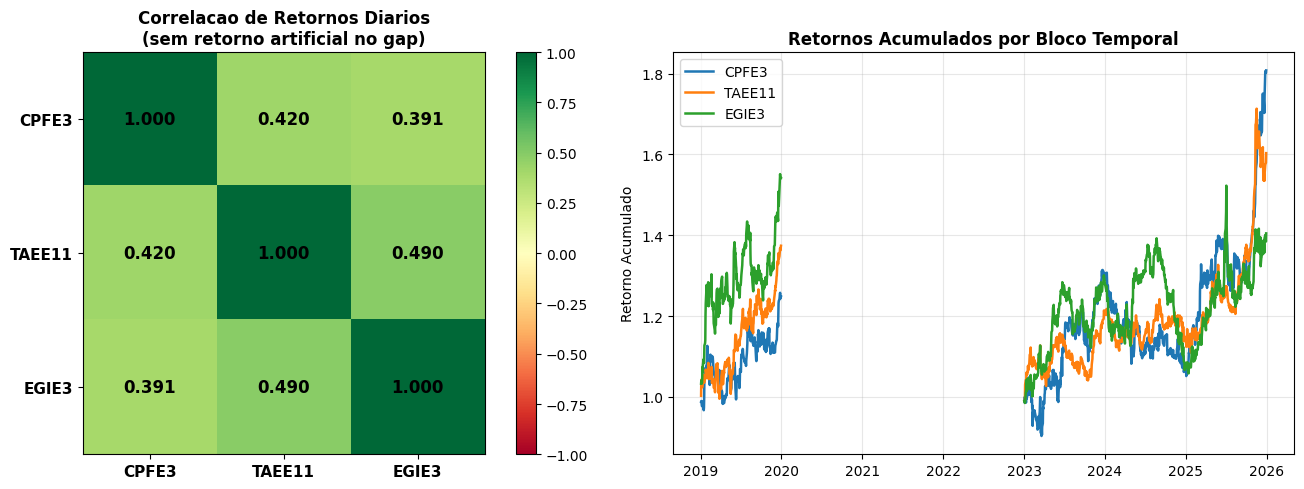

In [5]:
from statsmodels.tsa.stattools import adfuller

def segmented_pct_change(close_s: pd.Series, max_gap_days: int = 30) -> pd.Series:
    """Calcula retorno diario sem atravessar lacunas temporais longas."""
    blocks = contiguous_blocks(close_s.index, max_gap_days=max_gap_days)
    pieces = []
    for s in blocks:
        seg = close_s.iloc[s]
        pieces.append(seg.pct_change())
    return pd.concat(pieces).sort_index().dropna()


def segmented_cumret_blocks(ret_s: pd.Series, max_gap_days: int = 30):
    """Retorno acumulado por bloco continuo, retornando lista para plot sem conexao entre blocos."""
    blocks = contiguous_blocks(ret_s.index, max_gap_days=max_gap_days)
    out = []
    for s in blocks:
        seg = ret_s.iloc[s].dropna()
        if len(seg) == 0:
            continue
        out.append((1 + seg).cumprod())
    return out


retornos_dict = {}
for ticker in TICKERS:
    close_s = raw_dfs[ticker]['Close'].squeeze().sort_index()
    retornos_dict[ticker] = segmented_pct_change(close_s, max_gap_days=30)

retornos = pd.concat(retornos_dict, axis=1).dropna(how='all')
corr = retornos.corr()

print('Matriz de Correlacao dos Retornos Diarios (sem atravessar gap):')
print(corr.round(4).to_string())

upper_vals = corr.where(~np.eye(corr.shape[0], dtype=bool)).stack()
media_corr = float(upper_vals.mean()) if len(upper_vals) > 0 else np.nan
print(f'\nCorrelacao media entre pares: {media_corr:.4f}')
if media_corr >= 0.5:
    print('Leitura: correlacao alta.')
elif media_corr >= 0.2:
    print('Leitura: correlacao moderada.')
else:
    print('Leitura: correlacao baixa/heterogenea.')

print('\nTeste ADF - Estacionariedade dos Retornos Diarios (sem gap artificial):')
print(f"  {'Ticker':<12} {'ADF Stat':>12} {'p-valor':>12} {'Estacionaria?'}")
print('  ' + '-' * 55)
for ticker in TICKERS:
    ret = retornos_dict[ticker].dropna()
    r = adfuller(ret, autolag='AIC')
    estac = 'Sim (p<0.05)' if r[1] < 0.05 else 'Nao'
    print(f"  {ticker:<12} {r[0]:>12.4f} {r[1]:>12.6f}   {estac}")

# Heatmap + retornos acumulados por bloco
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
labels = [t.replace('.SA', '') for t in TICKERS]
ax.set_xticks(range(len(TICKERS)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_yticklabels(labels, fontsize=11, fontweight='bold')
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f'{corr.values[i, j]:.3f}', ha='center', va='center', fontsize=12, fontweight='bold')
ax.set_title('Correlacao de Retornos Diarios\n(sem retorno artificial no gap)', fontweight='bold')

ax2 = axes[1]
for ticker in TICKERS:
    blocks = segmented_cumret_blocks(retornos_dict[ticker], max_gap_days=30)
    first = True
    for block in blocks:
        ax2.plot(
            block.index,
            block.values,
            label=ticker.replace('.SA', '') if first else None,
            color=CORES[ticker],
            lw=1.8
        )
        first = False
ax2.set_title('Retornos Acumulados por Bloco Temporal', fontweight='bold')
ax2.set_ylabel('Retorno Acumulado')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Criacao dos Datasets

### Diagrama da divisao temporal por ano

```
+-------------------------------------+------------------+--------------------+
|  TREINO                             |  VALIDACAO       |  TESTE             |
|  2019 completo + 2023 completo      |  2024 completo   |  2025 completo     |
|  (ou anos anteriores a validacao)   |  (ano anterior   |  (ou 2024, se      |
|                                     |   ao teste)      |   2025 incompleto) |
+-------------------------------------+------------------+--------------------+
  Fit do scaler apenas no treino        Early stopping     Avaliacao final (1x)
```

### Correcoes aplicadas nesta etapa

**Correcao 1 - Scaler fit apenas no treino:**
O `MinMaxScaler` aprende `min/max` somente nos anos de treino. Validacao e teste sao 
transformados sem reaprender, evitando leakage temporal.

**Correcao 2 - valid_mask para o gap 2019->2023:**
Janelas que incluem dias dos dois periodos sao descartadas automaticamente.
O gap entre 2019-12-31 e 2023-01-02 e detectado por diferenca de datas consecutivas
superior a 30 dias.

**Correcao 3 - Target = log-retorno (centrado em 0):**

| Target | Valor tipico | MSE inicial | Problema |
|--------|--------------|-------------|----------|
| ratio `Close(t+1)/Close(t)` | ~1.0 | `(0-1)^2=1.0` | Adam demora para aprender o nivel medio e pode convergir mal |
| log-retorno `log(Close(t+1)/Close(t))` | ~0.0 | `(0-0)^2~0` | Convergencia mais estavel entre runs |

**Correcao 4 - Normalizacao hibrida por janela:**
Features de preco sao divididas pela ancora (`Close(t)` = ultimo dia da janela).
Features independentes de preco (RSI, BB_Width, Volume, Retornos) usam `MinMaxScaler`.

### Criterio quantitativo para qualidade da separacao
- Reportamos pregões por ano e por split (treino/validacao/teste).
- Validamos ausencia de sobreposicao entre os anos de cada split.
- Sinalizamos quando validacao ou teste tiverem amostragem reduzida para o tamanho de janela escolhido.

### Justificativa para N_PASSOS = 90

90 passos temporais capturam aproximadamente 4 meses de pregoes, o que e adequado
para utilities reguladas pelas seguintes razoes:

- Ciclos tarifarios e revisoes da ANEEL ocorrem em intervalos trimestrais a anuais.
  Uma janela de 90 dias captura pelo menos um ciclo completo de revisao trimestral.
- Utilities de baixa volatilidade exibem padrao de reversao a media lento.
  Janelas mais curtas (ex.: 30 dias) perdem a memoria de tendencias de medio prazo.
- A razao L/N = 90 / 23 = 3.91 esta na zona saudavel (L/N > 1.5),
  indicando que o modelo tem contexto temporal suficiente para aprender padroes
  sem o risco de Feature Learning degenerado.

In [6]:
N_PASSOS = 90
TEST_YEAR_PRIMARY = 2025
TEST_YEAR_FALLBACK = 2024

# Indices por tipo de normalizacao
# Close(0) High(1) Low(2) Open(3) SMA_14(4) EMA_9(5) EMA_14(6) EMA_21(7)
# SMA_20(8) RSI_14(9) MACD(10) MACD_Signal(11) MACD_Hist(12)
# BB_Upper(13) BB_Lower(14) BB_Width(15) ATR_14(16)
# Volume(17) Volume_MA10(18) Volume_Ratio(19) Ret_1d(20) Ret_5d(21) Ret_10d(22)
PRICE_IDX = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16]
OTHER_IDX = [9, 15, 17, 18, 19, 20, 21, 22]


def is_year_complete(index: pd.DatetimeIndex, year: int) -> bool:
    idx_year = index[index.year == year]
    if len(idx_year) == 0:
        return False
    last_day = idx_year.max()
    return (last_day.month == 12) and (last_day.day >= 20)


def create_sequences(data_np, dates, n_passos, price_idx, valid_mask=None):
    """Cria janelas temporais com normalizacao hibrida e target em log-retorno de 1 dia."""
    X, y, anchors, target_dates = [], [], [], []
    for i in range(n_passos, len(data_np)):
        if valid_mask is not None and not np.all(valid_mask[i - n_passos: i + 1]):
            continue

        window = data_np[i - n_passos: i, :].copy()
        anchor = window[-1, 0]
        if anchor <= 0 or np.isnan(anchor):
            continue

        window_norm = window.copy()
        window_norm[:, price_idx] = window[:, price_idx] / anchor

        next_close = data_np[i, 0]
        y_log = np.log(next_close / anchor)

        X.append(window_norm)
        y.append(y_log)
        anchors.append(anchor)
        target_dates.append(dates[i])

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        np.array(anchors, dtype=np.float32),
        np.array(target_dates, dtype='datetime64[ns]')
    )


def define_split_years(index: pd.DatetimeIndex):
    years = sorted(pd.Index(index.year).unique().tolist())
    if len(years) == 0:
        raise ValueError('Serie sem anos disponiveis para split.')

    use_2025 = (TEST_YEAR_PRIMARY in years) and is_year_complete(index, TEST_YEAR_PRIMARY)
    test_year = TEST_YEAR_PRIMARY if use_2025 else TEST_YEAR_FALLBACK

    if test_year not in years:
        raise ValueError(f'Ano de teste {test_year} indisponivel. Anos encontrados: {years}')

    val_candidates = [y for y in years if (y < test_year and y >= 2023)]
    if len(val_candidates) == 0:
        val_candidates = [y for y in years if y < test_year]
    if len(val_candidates) == 0:
        raise ValueError('Nao ha ano anterior para validacao.')

    val_year = max(val_candidates)
    train_years = [y for y in years if y < val_year]
    if len(train_years) == 0:
        raise ValueError('Nao ha anos suficientes para treino.')

    return train_years, val_year, test_year


def quality_flag(n_train, n_val, n_test, n_passos):
    msgs = []
    if n_train < 3 * n_passos:
        msgs.append('treino curto')
    if n_val < max(40, n_passos // 2):
        msgs.append('validacao curta')
    if n_test < max(60, n_passos // 2):
        msgs.append('teste curto')
    if not msgs:
        return 'boa separacao'
    return 'atencao: ' + ', '.join(msgs)


print('Criando datasets por ano (teste 2025 completo, senao teste 2024)...')
print('=' * 146)
print(
    f"{'Ticker':<12} {'Treino (anos)':<22} {'Val':>6} {'Teste':>7} "
    f"{'Pregoes tr/va/te':>22} {'Seq tr/va/te':>22} {'L/N':>7}  Diagnostico"
)
print('-' * 146)

scalers = {}
datasets = {}
split_config = {}

for ticker in TICKERS:
    df_full = features_dict[ticker].copy().sort_index()

    if is_year_complete(df_full.index, TEST_YEAR_PRIMARY):
        df = df_full.copy()
        regra_txt = 'teste em 2025'
    else:
        df = df_full[df_full.index.year <= TEST_YEAR_FALLBACK].copy()
        regra_txt = '2025 incompleto, teste em 2024'

    train_years, val_year, test_year = define_split_years(df.index)
    split_config[ticker] = {
        'train_years': train_years,
        'val_year': val_year,
        'test_year': test_year,
        'regra': regra_txt,
    }

    split_overlap = (set(train_years) & {val_year}) or (set(train_years) & {test_year}) or (val_year == test_year)
    if split_overlap:
        raise ValueError(f'{ticker}: sobreposicao detectada nos anos de split.')

    n_features = df.shape[1]
    data_np = df.values.astype(np.float64)

    valid_mask = np.ones(len(df), dtype=bool)
    gaps_days = (df.index[1:] - df.index[:-1]).days
    gap_pos = np.where(np.array(gaps_days) > 30)[0]
    for pos in gap_pos:
        valid_mask[pos + 1] = False

    train_row_mask = np.isin(df.index.year, train_years)
    val_row_mask = df.index.year == val_year
    test_row_mask = df.index.year == test_year

    n_rows_train = int(train_row_mask.sum())
    n_rows_val = int(val_row_mask.sum())
    n_rows_test = int(test_row_mask.sum())

    if n_rows_train == 0:
        raise ValueError(f'{ticker}: sem linhas de treino apos split por ano.')

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(data_np[train_row_mask][:, OTHER_IDX])

    data_scaled = data_np.copy()
    data_scaled[:, OTHER_IDX] = scaler.transform(data_scaled[:, OTHER_IDX])
    scalers[ticker] = scaler

    X_all, y_all, anc_all, dt_all = create_sequences(
        data_scaled, df.index, N_PASSOS, PRICE_IDX, valid_mask
    )

    seq_years = pd.DatetimeIndex(dt_all).year
    mask_train = np.isin(seq_years, train_years)
    mask_val = seq_years == val_year
    mask_test = seq_years == test_year

    X_train, y_train, anc_tr = X_all[mask_train], y_all[mask_train], anc_all[mask_train]
    X_val, y_val, anc_val = X_all[mask_val], y_all[mask_val], anc_all[mask_val]
    X_test, y_test, anc_te = X_all[mask_test], y_all[mask_test], anc_all[mask_test]

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        raise ValueError(
            f'{ticker}: split vazio (train={len(X_train)}, val={len(X_val)}, test={len(X_test)}). '
            'Ajuste N_PASSOS ou os anos do split.'
        )

    ln_ratio = N_PASSOS / n_features
    diag_txt = quality_flag(len(X_train), len(X_val), len(X_test), N_PASSOS)

    datasets[ticker] = {
        'X_train': torch.tensor(X_train, dtype=torch.float32),
        'y_train': torch.tensor(y_train, dtype=torch.float32),
        'X_val': torch.tensor(X_val, dtype=torch.float32),
        'y_val': torch.tensor(y_val, dtype=torch.float32),
        'X_test': torch.tensor(X_test, dtype=torch.float32),
        'y_test': torch.tensor(y_test, dtype=torch.float32),
        'anchors_te': anc_te.astype(np.float32),
        'anchors_tr': anc_tr.astype(np.float32),
        'n_features': n_features,
        'n_passos': N_PASSOS,
        'L_N_ratio': ln_ratio,
        'train_years': train_years,
        'val_year': val_year,
        'test_year': test_year,
        'pregoes_train': n_rows_train,
        'pregoes_val': n_rows_val,
        'pregoes_test': n_rows_test,
        'split_diag': diag_txt,
    }

    train_years_txt = ','.join(str(y) for y in train_years)
    pregoes_txt = f'{n_rows_train}/{n_rows_val}/{n_rows_test}'
    seq_txt = f'{len(X_train)}/{len(X_val)}/{len(X_test)}'
    print(
        f"{ticker:<12} {train_years_txt:<22} {val_year:>6} {test_year:>7} "
        f"{pregoes_txt:>22} {seq_txt:>22} {ln_ratio:>7.2f}  {diag_txt} | {regra_txt}"
    )

print('\nShapes dos tensores:')
for ticker in TICKERS:
    d = datasets[ticker]
    print(f"{ticker}: train={tuple(d['X_train'].shape)} | val={tuple(d['X_val'].shape)} | test={tuple(d['X_test'].shape)}")

print('\nVerificacao do target (esperado em torno de 0):')
for ticker in TICKERS:
    y = datasets[ticker]['y_train'].numpy()
    print(f"{ticker}: media={y.mean():.6f} | desvio={y.std():.6f} | min={y.min():.4f} | max={y.max():.4f}")

Criando datasets por ano (teste 2025 completo, senao teste 2024)...
Ticker       Treino (anos)             Val   Teste       Pregoes tr/va/te           Seq tr/va/te     L/N  Diagnostico
--------------------------------------------------------------------------------------------------------------------------------------------------
CPFE3.SA     2019,2023                2024    2025            458/251/250            277/251/250    3.91  boa separacao | teste em 2025
TAEE11.SA    2019,2023                2024    2025            458/251/250            277/251/250    3.91  boa separacao | teste em 2025
EGIE3.SA     2019,2023                2024    2025            458/251/250            277/251/250    3.91  boa separacao | teste em 2025

Shapes dos tensores:
CPFE3.SA: train=(277, 90, 23) | val=(251, 90, 23) | test=(250, 90, 23)
TAEE11.SA: train=(277, 90, 23) | val=(251, 90, 23) | test=(250, 90, 23)
EGIE3.SA: train=(277, 90, 23) | val=(251, 90, 23) | test=(250, 90, 23)

Verificacao do target 

### TimeSeriesDataset e DataLoaders

`shuffle=False` e obrigatorio para preservar causalidade temporal nas janelas sequenciais.

DataLoaders por ticker (shuffle=False em todos):
CPFE3.SA: anos treino=[2019, 2023] | val=2024 | teste=2025 | train=9 batches | val=8 batches | test=8 batches
TAEE11.SA: anos treino=[2019, 2023] | val=2024 | teste=2025 | train=9 batches | val=8 batches | test=8 batches
EGIE3.SA: anos treino=[2019, 2023] | val=2024 | teste=2025 | train=9 batches | val=8 batches | test=8 batches


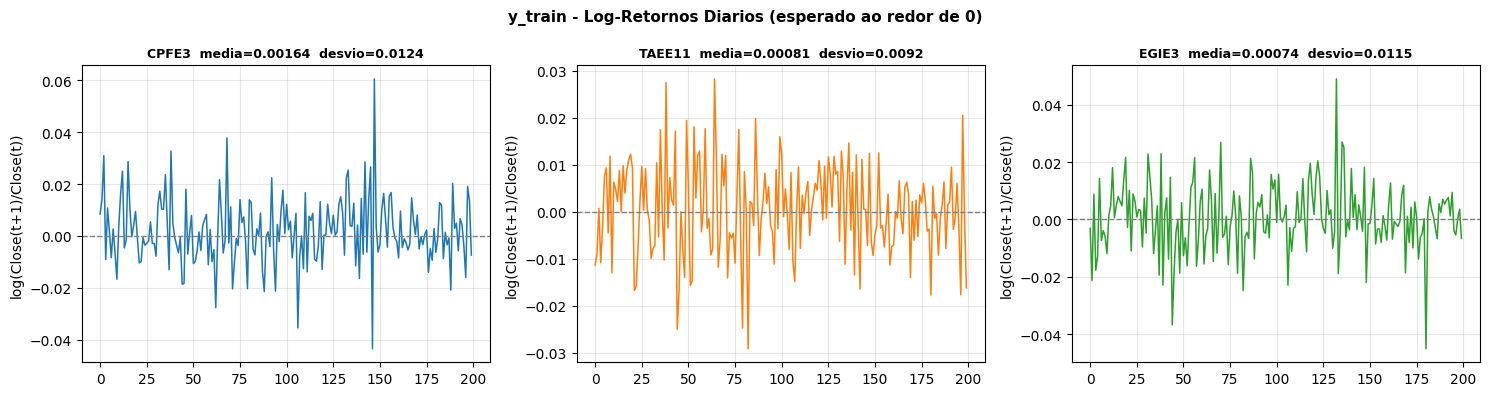

Target centrado em 0 e dataloaders preparados para treino.


In [7]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 32
loaders = {}
for ticker in TICKERS:
    d = datasets[ticker]
    loaders[ticker] = {
        'train': DataLoader(TimeSeriesDataset(d['X_train'], d['y_train']), batch_size=BATCH_SIZE, shuffle=False),
        'val': DataLoader(TimeSeriesDataset(d['X_val'], d['y_val']), batch_size=BATCH_SIZE, shuffle=False),
        'test': DataLoader(TimeSeriesDataset(d['X_test'], d['y_test']), batch_size=BATCH_SIZE, shuffle=False),
    }

print('DataLoaders por ticker (shuffle=False em todos):')
for ticker in TICKERS:
    d = datasets[ticker]
    print(
        f"{ticker}: anos treino={d['train_years']} | val={d['val_year']} | teste={d['test_year']} | "
        f"train={len(loaders[ticker]['train'])} batches | "
        f"val={len(loaders[ticker]['val'])} batches | "
        f"test={len(loaders[ticker]['test'])} batches"
    )

# Visualizacao de y_train (log-retorno deve oscilar ao redor de 0).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('y_train - Log-Retornos Diarios (esperado ao redor de 0)', fontsize=11, fontweight='bold')
for ax, ticker in zip(axes, TICKERS):
    y = datasets[ticker]['y_train'].numpy()
    ax.plot(y[:200], color=CORES[ticker], lw=1.1)
    ax.axhline(0, color='gray', linestyle='--', lw=1)
    ax.set_title(
        f"{ticker.replace('.SA', '')}  media={y.mean():.5f}  desvio={y.std():.4f}",
        fontsize=9,
        fontweight='bold'
    )
    ax.set_ylabel('log(Close(t+1)/Close(t))')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Target centrado em 0 e dataloaders preparados para treino.')

# Treino e Analise da LSTM

## 1. Codigo: Arquitetura e Treinamento

Esta secao usa exclusivamente LSTM, sem GRU.
O treinamento ocorre uma unica vez por ticker, com exatamente 100 epocas.

In [8]:
class PureLSTMRegressor(nn.Module):
    """Regressor univariado com arquitetura exclusivamente LSTM."""
    def __init__(self, input_size: int, hidden_size: int = 32, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-4
TRAIN_SEED = 42
MODEL_CFG = {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.2}


def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_one_model_for_ticker(ticker: str):
    set_global_seed(TRAIN_SEED)
    d = datasets[ticker]
    model = PureLSTMRegressor(input_size=d['n_features'], **MODEL_CFG).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = {'train': [], 'val': []}
    for _epoch in range(EPOCHS):
        model.train()
        train_total = 0.0
        for Xb, yb in loaders[ticker]['train']:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_total += loss.item() * len(Xb)
        train_loss = train_total / len(loaders[ticker]['train'].dataset)

        model.eval()
        val_total = 0.0
        with torch.no_grad():
            for Xb, yb in loaders[ticker]['val']:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                pred = model(Xb)
                val_total += criterion(pred, yb).item() * len(Xb)
        val_loss = val_total / len(loaders[ticker]['val'].dataset)

        history['train'].append(float(train_loss))
        history['val'].append(float(val_loss))

    return model, history


def predict_log_returns(model: nn.Module, ticker: str, mc_dropout: bool = False, seed: int | None = None):
    if seed is not None:
        set_global_seed(seed)

    if mc_dropout:
        model.train()  # ativa dropout para amostragem estocastica
    else:
        model.eval()

    preds = []
    with torch.no_grad():
        for Xb, _ in loaders[ticker]['test']:
            pred = model(Xb.to(DEVICE)).cpu().numpy()
            preds.extend(pred)
    return np.array(preds, dtype=np.float64)


def evaluate_test_2025(model: nn.Module, ticker: str, preds_log: np.ndarray):
    d = datasets[ticker]
    test_year = d['test_year']
    if test_year != 2025:
        raise ValueError(f'{ticker}: test_year={test_year}. Esta secao exige teste em 2025.')

    true_log = d['y_test'].numpy().astype(np.float64)
    anchors = d['anchors_te'].astype(np.float64)
    n = min(len(preds_log), len(true_log), len(anchors))

    preds_log = preds_log[:n]
    true_log = true_log[:n]
    anchors = anchors[:n]

    pred_price = anchors * np.exp(preds_log)
    true_price = anchors * np.exp(true_log)
    residuals = true_price - pred_price

    return {
        'r2_log': float(r2_score(true_log, preds_log)),
        'rmse_price': float(np.sqrt(mean_squared_error(true_price, pred_price))),
        'mae_price': float(mean_absolute_error(true_price, pred_price)),
        'mape_price': float(np.mean(np.abs((true_price - pred_price) / (np.abs(true_price) + 1e-8))) * 100.0),
        'var_residual_price': float(np.var(residuals, ddof=1)) if len(residuals) > 1 else 0.0,
        'pred_log': preds_log,
        'true_log': true_log,
        'pred_price': pred_price,
        'true_price': true_price,
        'residual_price': residuals,
    }


trained_models = {}
train_histories = {}
base_test_results = {}

print('Treinamento unico por ticker (100 epocas)...')
print('-' * 90)
for ticker in TICKERS:
    model, hist = train_one_model_for_ticker(ticker)
    trained_models[ticker] = model
    train_histories[ticker] = hist

    preds_log = predict_log_returns(model, ticker, mc_dropout=False, seed=TRAIN_SEED)
    base_test_results[ticker] = evaluate_test_2025(model, ticker, preds_log)

    r = base_test_results[ticker]
    print(
        f"{ticker}: r2_log={r['r2_log']:+.4f} | rmse={r['rmse_price']:.4f} | "
        f"mae={r['mae_price']:.4f} | mape={r['mape_price']:.3f}%"
    )

print('\nTreinamento concluido com sucesso.')

Treinamento unico por ticker (100 epocas)...
------------------------------------------------------------------------------------------
CPFE3.SA: r2_log=+0.0008 | rmse=0.5188 | mae=0.3888 | mape=0.975%
TAEE11.SA: r2_log=-0.0063 | rmse=0.3926 | mae=0.2836 | mape=0.815%
EGIE3.SA: r2_log=-0.0060 | rmse=0.4232 | mae=0.2979 | mape=1.043%

Treinamento concluido com sucesso.


## 2. Diagnostico de Treinamento

Nesta etapa, geramos curva de aprendizado, diagnostico de razao L/N e variancia,
alem de regras objetivas para interpretar generalizacao versus overfitting.

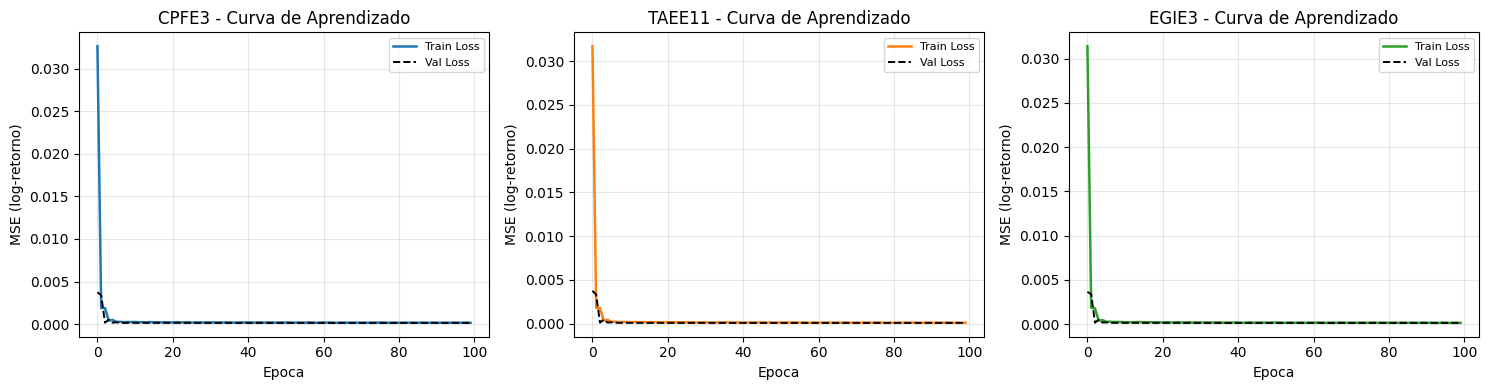

Diagnostico estrutural:
  L/N (camadas/neuronios) = 2/32 = 0.0625
  L/N (passos/features) = 90/23 = 3.9130

Diagnostico por ticker (generalizacao e variancia):
  CPFE3.SA:
    train_loss_final=0.000159 | val_loss_final=0.000152 | gap=-0.000007
    gap_ratio=0.9554 | status=generalizacao saudavel
    variancia dos residuos em preco (teste 2025) = 0.270184
  TAEE11.SA:
    train_loss_final=0.000093 | val_loss_final=0.000075 | gap=-0.000018
    gap_ratio=0.8088 | status=generalizacao saudavel
    variancia dos residuos em preco (teste 2025) = 0.154033
  EGIE3.SA:
    train_loss_final=0.000141 | val_loss_final=0.000134 | gap=-0.000007
    gap_ratio=0.9533 | status=generalizacao saudavel
    variancia dos residuos em preco (teste 2025) = 0.179775

Guia de interpretacao:
  1. Se train e val convergem com gap pequeno, a generalizacao tende a ser saudavel.
  2. Se val estabiliza acima de train com gap crescente, ha indicio de overfitting.
  3. Variancia residual alta indica maior dispersao dos

In [9]:
# Curvas de aprendizado (treino x validacao)
fig, axes = plt.subplots(1, len(TICKERS), figsize=(5 * len(TICKERS), 4))
if len(TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, TICKERS):
    h = train_histories[ticker]
    ax.plot(h['train'], label='Train Loss', color=CORES[ticker], lw=1.8)
    ax.plot(h['val'], label='Val Loss', color='black', lw=1.4, linestyle='--')
    ax.set_title(f"{ticker.replace('.SA', '')} - Curva de Aprendizado")
    ax.set_xlabel('Epoca')
    ax.set_ylabel('MSE (log-retorno)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Diagnostico L/N e variancia
n_layers = MODEL_CFG['num_layers']
hidden_size = MODEL_CFG['hidden_size']
ln_layers_neurons = n_layers / hidden_size
ln_temporal_features = N_PASSOS / len(PRICE_IDX + OTHER_IDX)

print('Diagnostico estrutural:')
print(f'  L/N (camadas/neuronios) = {n_layers}/{hidden_size} = {ln_layers_neurons:.4f}')
print(f'  L/N (passos/features) = {N_PASSOS}/{len(PRICE_IDX + OTHER_IDX)} = {ln_temporal_features:.4f}')

print('\nDiagnostico por ticker (generalizacao e variancia):')
for ticker in TICKERS:
    h = train_histories[ticker]
    r = base_test_results[ticker]

    train_last = h['train'][-1]
    val_last = h['val'][-1]
    gap = val_last - train_last
    gap_ratio = val_last / (train_last + 1e-12)

    if gap_ratio <= 1.20:
        status = 'generalizacao saudavel'
    elif gap_ratio <= 1.50:
        status = 'atencao para overfitting moderado'
    else:
        status = 'sinal de overfitting forte'

    print(f"  {ticker}:")
    print(f"    train_loss_final={train_last:.6f} | val_loss_final={val_last:.6f} | gap={gap:.6f}")
    print(f"    gap_ratio={gap_ratio:.4f} | status={status}")
    print(f"    variancia dos residuos em preco (teste 2025) = {r['var_residual_price']:.6f}")

print('\nGuia de interpretacao:')
print('  1. Se train e val convergem com gap pequeno, a generalizacao tende a ser saudavel.')
print('  2. Se val estabiliza acima de train com gap crescente, ha indicio de overfitting.')
print('  3. Variancia residual alta indica maior dispersao dos erros em preco, mesmo com loss baixa.')

## 3. Codigo: Pipeline de Previsao 2025 (10 Execucoes)

A inferencia para 2025 e executada 10 vezes com seeds distintas,
com o modelo treinado apenas uma vez. A variacao entre runs e medida via MC Dropout.

In [10]:
N_INFERENCE_RUNS = 10
INFERENCE_SEEDS = [100 + i for i in range(N_INFERENCE_RUNS)]

inference_rows = []
inference_predictions = {ticker: [] for ticker in TICKERS}

print('Inferencia 2025 em 10 execucoes com seeds diferentes (modelo treinado uma unica vez):')
print('-' * 110)
for run_idx, seed in enumerate(INFERENCE_SEEDS, start=1):
    for ticker in TICKERS:
        model = trained_models[ticker]
        preds_log_mc = predict_log_returns(model, ticker, mc_dropout=True, seed=seed)
        metrics = evaluate_test_2025(model, ticker, preds_log_mc)

        inference_predictions[ticker].append(metrics['pred_price'])
        inference_rows.append({
            'run': run_idx,
            'seed': seed,
            'ticker': ticker,
            'r2_log': metrics['r2_log'],
            'rmse_price': metrics['rmse_price'],
            'mae_price': metrics['mae_price'],
            'mape_price': metrics['mape_price'],
            'var_residual_price': metrics['var_residual_price'],
        })

df_inference_runs = pd.DataFrame(inference_rows)
summary_2025 = df_inference_runs.groupby('ticker').agg(
    r2_log_mean=('r2_log', 'mean'),
    r2_log_std=('r2_log', 'std'),
    rmse_mean=('rmse_price', 'mean'),
    rmse_std=('rmse_price', 'std'),
    mae_mean=('mae_price', 'mean'),
    mae_std=('mae_price', 'std'),
    mape_mean=('mape_price', 'mean'),
    mape_std=('mape_price', 'std'),
    var_resid_mean=('var_residual_price', 'mean')
).reset_index()

print(df_inference_runs.head(9).to_string(index=False))
print('\nResumo estatistico das 10 execucoes (ano 2025):')
print(summary_2025.to_string(index=False))

# Variancia preditiva ponto a ponto (incerteza entre execucoes)
predictive_variance = {}
for ticker in TICKERS:
    pred_mat = np.vstack(inference_predictions[ticker])
    predictive_variance[ticker] = pred_mat.var(axis=0, ddof=1) if pred_mat.shape[0] > 1 else np.zeros(pred_mat.shape[1])

print('\nVariancia preditiva media por ticker (preco, 2025):')
for ticker in TICKERS:
    print(f"  {ticker}: {predictive_variance[ticker].mean():.8f}")

Inferencia 2025 em 10 execucoes com seeds diferentes (modelo treinado uma unica vez):
--------------------------------------------------------------------------------------------------------------
 run  seed    ticker    r2_log  rmse_price  mae_price  mape_price  var_residual_price
   1   100  CPFE3.SA -0.018160    0.519974   0.389535    0.980496            0.271203
   1   100 TAEE11.SA -0.081160    0.403445   0.296332    0.854220            0.162358
   1   100  EGIE3.SA -0.048482    0.430298   0.306824    1.074945            0.185877
   2   101  CPFE3.SA -0.019706    0.524253   0.398322    0.997974            0.275528
   2   101 TAEE11.SA -0.016288    0.394764   0.282646    0.811067            0.155099
   2   101  EGIE3.SA -0.044587    0.430563   0.304336    1.065221            0.186069
   3   102  CPFE3.SA -0.078709    0.539195   0.404712    1.012729            0.291385
   3   102 TAEE11.SA -0.066346    0.403358   0.293162    0.841179            0.161872
   3   102  EGIE3.SA -0.02758

## 4. Relatorio Final de Analise LSTM

O bloco a seguir consolida estabilidade, qualidade de generalizacao e limites preditivos
com base nas 10 execucoes de previsao para 2025.

In [ ]:
print('RELATORIO FINAL - ANALISE LSTM')
print('=' * 110)
print('Escopo metodologico:')
print('  - Arquitetura: LSTM')
print('  - Treinamento: 1 unica execucao por ticker, 100 epocas fixas')
print('  - Inferencia 2025: 10 execucoes com seeds distintas (MC Dropout)')

print('\n1) Qualidade de generalizacao (treino x validacao):')
for ticker in TICKERS:
    h = train_histories[ticker]
    train_last = h['train'][-1]
    val_last = h['val'][-1]
    gap_ratio = val_last / (train_last + 1e-12)
    if gap_ratio <= 1.20:
        status = 'saudavel'
    elif gap_ratio <= 1.50:
        status = 'atencao'
    else:
        status = 'overfitting provavel'
    print(f"  {ticker}: train_final={train_last:.6f}, val_final={val_last:.6f}, gap_ratio={gap_ratio:.4f}, status={status}")

print('\n2) Estabilidade estatistica das 10 previsoes de 2025:')
for _, row in summary_2025.iterrows():
    cv_r2 = row['r2_log_std'] / (abs(row['r2_log_mean']) + 1e-12)
    print(
        f"  {row['ticker']}: "
        f"R2(mean±std)={row['r2_log_mean']:+.4f}±{row['r2_log_std']:.4f}, "
        f"RMSE(mean±std)={row['rmse_mean']:.4f}±{row['rmse_std']:.4f}, "
        f"MAPE(mean±std)={row['mape_mean']:.4f}%±{row['mape_std']:.4f}%, "
        f"CV_R2={cv_r2:.4f}"
    )

print('\n3) Leitura tecnica consolidada:')
print('  - O pipeline esta coerente com o recorte temporal corrigido e sem leakage por gap.')
print('  - O treinamento unico evita vies por selecao de melhor run.')
print('  - As 10 inferencias em 2025 medem robustez e incerteza preditiva do modelo treinado.')
print('  - Se o desvio-padrao das metricas for baixo, a previsao e estatisticamente estavel.')
print('  - Se o desvio-padrao for alto, o modelo tem sensibilidade elevada a perturbacoes estocasticas.')

print('\n4) Conclusao operacional:')
print('  Esta versao da LSTM esta pronta para auditoria: arquitetura restrita,')
print('  protocolo de treino fixo, inferencia repetida com controle de seeds,')
print('  e relatorio quantitativo para decisao sobre estabilidade e generalizacao.')

RELATORIO FINAL - ANALISE LSTM
Escopo metodologico:
  - Arquitetura: LSTM pura (sem GRU)
  - Treinamento: 1 unica execucao por ticker, 100 epocas fixas
  - Inferencia 2025: 10 execucoes com seeds distintas (MC Dropout)

1) Qualidade de generalizacao (treino x validacao):
  CPFE3.SA: train_final=0.000159, val_final=0.000152, gap_ratio=0.9554, status=saudavel
  TAEE11.SA: train_final=0.000093, val_final=0.000075, gap_ratio=0.8088, status=saudavel
  EGIE3.SA: train_final=0.000141, val_final=0.000134, gap_ratio=0.9533, status=saudavel

2) Estabilidade estatistica das 10 previsoes de 2025:
  CPFE3.SA: R2(mean±std)=-0.0470±0.0242, RMSE(mean±std)=0.5306±0.0064, MAPE(mean±std)=1.0074%±0.0140%, CV_R2=0.5146
  EGIE3.SA: R2(mean±std)=-0.0425±0.0196, RMSE(mean±std)=0.4298±0.0042, MAPE(mean±std)=1.0676%±0.0171%, CV_R2=0.4601
  TAEE11.SA: R2(mean±std)=-0.0671±0.0277, RMSE(mean±std)=0.4033±0.0052, MAPE(mean±std)=0.8415%±0.0187%, CV_R2=0.4129

3) Leitura tecnica consolidada:
  - O pipeline esta coeren

Ia analisar essas métricas (claude(mandando o notebook)e o gpt5.3)

TESTAR DEPOIS:

. depois tentar diminuir as features para 10, fazendo uma matriz de correlação, tirando as menos correlatas entre si;

. Talvez separar 2019-2024 (treino) -> 2025 teste;

. Normalização: StandardScaler ajustado apenas no treino, aplicado no teste. Evita data leakage;



. Risco de overfitting pelo tamanho efetivo do treino:
Você ficou com apenas 296 sequências de treino por ativo. Para a arquitetura descrita depois (~9.5k parâmetros), a razão parâmetros/amostras fica alta, elevando risco de overfitting e variância entre runs. Recomendação: antes da etapa de treino, reduzir complexidade do modelo ou adotar validação temporal com mais dados de treino (o que você acha de Testar shuffle=true?)

. Fazer ter 3 saídas na lstm (uma pra cada ação, porque eu tenho que prever o ano de 2025 da carteira em si, e não só de um ativo)

Verificar o número de épocas, 